# Phase 0 — Full Pipeline: AIS Density -> Preprocessing -> Annotation -> Benchmark

## Final Version -- reduced test set (5 scenes), geographic targeting by AIS density

Full sequence, in strict dependency order:

```
[0] Setup + Token Security (read from Colab Secrets, never in plain text)
[1] AIS Density Map -- BEFORE any CDSE download
[2] Selection of 5 CDSE scenes targeted on high-density zones
[3] CRS/GCP Verification -- blocking, never use guessed reconstruction
[4] ONE scene processed as a test -- mandatory stop, human validation
[5] Batch of the remaining 4 scenes -- ONLY after explicit validation
[6] Global sanity check
[7] mAP / Precision / Recall benchmark by pipeline
[8] Inter-pipeline KS Test
[9] Final Export
```

## Prerequisites before launching

- The GFW token must be added to **Colab Secrets** (key icon 🔑 in the left sidebar) under the name `GFW_API_TOKEN`.
- CDSE credentials (email + password) are also recommended via Colab Secrets, under `CDSE_USERNAME` and `CDSE_PASSWORD`.
- The Phase I ONNX model must be on Drive for the benchmark to calculate a real mAP.

In [2]:
# Cell 1 -- Dependencies
!pip install -q rasterio scipy numpy tqdm matplotlib pillow psutil httpx onnxruntime

import os, sys, json, gc, time, math, re, zipfile, logging, shutil, urllib
import xml.etree.ElementTree as ET
from pathlib import Path
from typing import Dict, List, Tuple, Any, Optional
from datetime import datetime, timedelta

import numpy as np
import rasterio
from rasterio.warp import transform as warp_transform
from rasterio.windows import Window
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import uniform_filter
from scipy.stats import ks_2samp
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import psutil
import httpx

print("Dependencies installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 49.8 MB/s eta 0:00:00
Dependencies installed successfully.


In [3]:
# Cell 2 -- Drive Mounting

from google.colab import drive
drive.mount('/content/drive')

ROOT_SAFE_DIR = Path("/content/drive/MyDrive/maritime_sar_processing/scenes/")
ROOT_SAFE_DIR.mkdir(parents=True, exist_ok=True)
print(f"Scenes directory: {ROOT_SAFE_DIR}")

Mounted at /content/drive
Scenes directory: /content/drive/MyDrive/maritime_sar_processing/scenes


In [4]:
# Cell 3 -- Configuration and Constants

logging.basicConfig(level=logging.INFO, format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger("phase0")

WORK_DIR = Path("/content/phase0")
TILES_DIR = WORK_DIR / "data" / "tiles"
RESULTS_DIR = WORK_DIR / "data" / "results"
VIZ_DIR = WORK_DIR / "data" / "viz"
DENSITY_DIR = WORK_DIR / "data" / "density"
for d in [TILES_DIR, RESULTS_DIR, VIZ_DIR, DENSITY_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# SAR Parameters
TILE_SIZE = 512
OVERLAP = 0.5
NODATA_THRESHOLD = 0.30
DB_MIN, DB_MAX = -30.0, 0.0
PIPELINES = ["A", "B", "C", "D"]
POLARIZATION = "vv"

# GFW Parameters
GFW_MARGIN_DEG = 0.01
N_EMPTY_TILES_PER_SCENE = 80
MAX_TILES_PER_SCENE_HARD_CAP = 600

# Geographic Targeting Parameters -- NEW
MOROCCO_BBOX = [-17.0, 27.0, -1.0, 36.0]  # [lon_min, lat_min, lon_max, lat_max]
DENSITY_CELL_SIZE_DEG = 0.5   # ~55 km -- density map granularity
DENSITY_LOOKBACK_DAYS = 30    # recent period queried for AIS density
N_TARGET_ZONES = 5            # number of high-density zones to target
MAX_TEST_SCENES = 5           # STRICT test batch -- do not exceed without explicit decision

def get_ram_mb() -> float:
    return psutil.Process(os.getpid()).memory_info().rss / (1024 ** 2)

def haversine_m(lat1, lon1, lat2, lon2) -> float:
    R = 6371000.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlmb = math.radians(lon2 - lon1)
    a = math.sin(dphi/2)**2 + math.cos(p1)*math.cos(p2)*math.sin(dlmb/2)**2
    return 2 * R * math.asin(math.sqrt(a))

print(f"Working directory: {WORK_DIR}")
print(f"Initial RAM: {get_ram_mb():.0f} MB")
print(f"Test batch: {MAX_TEST_SCENES} scenes maximum")

Working directory: /content/phase0
Initial RAM: 187 MB
Test batch: 5 scenes maximum


In [5]:
# Cell 4 -- GFW Configuration -- SECURED via Colab Secrets
#
# The token is NEVER written in plain text. It must be added to
# Colab Secrets (key icon in the sidebar) under the name GFW_API_TOKEN.

from google.colab import userdata

try:
    GFW_API_TOKEN = userdata.get("GFW_API_TOKEN")
except Exception as e:
    raise RuntimeError(
        "GFW_API_TOKEN not found in Colab Secrets. "
        "Add it via the key icon in the left sidebar, "
        "name it exactly 'GFW_API_TOKEN', and enable notebook access."
    )

assert GFW_API_TOKEN, "GFW_API_TOKEN is empty in Colab Secrets."

GFW_BASE_URL = "https://gateway.api.globalfishingwatch.org/v3"
GFW_EVENTS = f"{GFW_BASE_URL}/events"
GFW_REPORT = f"{GFW_BASE_URL}/4wings/report"
AIS_PRESENCE_DATASET = "public-global-presence:latest"
AIS_OFF_DATASET = "public-global-gaps-events:latest"

_gfw_headers = {
    "Authorization": f"Bearer {GFW_API_TOKEN}",
    "Content-Type": "application/json",
    "Accept": "application/json",
}
print("GFW Client configured (token loaded from Colab Secrets).")

GFW Client configured (token loaded from Colab Secrets).


In [6]:
# Cell 5 -- GFW Helpers (response parsing)

def _bbox_polygon(bbox: List[float]) -> Dict[str, Any]:
    lon_min, lat_min, lon_max, lat_max = bbox
    return {
        "type": "Polygon",
        "coordinates": [[
            [lon_min, lat_min], [lon_max, lat_min],
            [lon_max, lat_max], [lon_min, lat_max],
            [lon_min, lat_min],
        ]],
    }

def _normalize_response_entries(response: Dict[str, Any]) -> List[Dict[str, Any]]:
    """
    Normalizes GFW responses. Explicitly handles nested format confirmed
    empirically: entries[0]["public-global-presence:v4.0"] contains the list.
    """
    if response is None:
        return []
    for field in ("entries", "results", "data", "rows", "features"):
        if field in response and isinstance(response[field], list):
            raw_list = response[field]
            if len(raw_list) == 0:
                continue
            if isinstance(raw_list[0], dict) and any(
                isinstance(v, list) for v in raw_list[0].values()
            ):
                flattened = []
                for wrapper in raw_list:
                    if not isinstance(wrapper, dict):
                        continue
                    for key, sublist in wrapper.items():
                        if isinstance(sublist, list):
                            flattened.extend(sublist)
                if flattened:
                    logger.info(f"Nested format detected and flattened: {len(flattened)} entries")
                    return flattened
            return raw_list
    for key, value in response.items():
        if isinstance(value, list) and len(value) > 0 and isinstance(value[0], dict):
            return value
    return []

def _extract_lat_lon(event: Any) -> Tuple[Optional[float], Optional[float]]:
    """Robustly extracts coordinates, handling non-dict types that may appear in GFW event streams."""
    if not isinstance(event, dict):
        return None, None

    if "lat" in event and "lon" in event:
        return float(event["lat"]), float(event["lon"])
    if "latitude" in event and "longitude" in event:
        return float(event["latitude"]), float(event["longitude"])

    geometry = event.get("geometry")
    if isinstance(geometry, dict):
        coords = geometry.get("coordinates")
        if isinstance(coords, list) and len(coords) >= 2:
            return float(coords[1]), float(coords[0])
    return None, None

print("GFW Helpers loaded with robust type checking.")

GFW Helpers loaded with robust type checking.


In [24]:
# Cell 6 -- Full GFW Client (AIS Presence + Dark Vessels)

def gfw_get_ais_presence(bbox: List[float], date_start: str, date_end: str, limit: int = 500) -> List[Dict[str, Any]]:
    """AIS Vessel Presence via POST /v3/4wings/report."""
    geometry = _bbox_polygon(bbox)
    query_params = {
        "datasets[0]": AIS_PRESENCE_DATASET,
        "date-range": f"{date_start},{date_end}",
        "spatial-resolution": "LOW",
        "temporal-resolution": "DAILY",
        "format": "JSON",
    }
    body_params = {"geojson": geometry, "limit": limit}
    try:
        with httpx.Client(timeout=30.0) as client:
            r = client.post(GFW_REPORT, headers=_gfw_headers, params=query_params, json=body_params)
        if r.status_code != 200:
            logger.warning(f"GFW AIS presence failed ({r.status_code}): {r.text[:200]}")
            return []
        entries = _normalize_response_entries(r.json())
        normalized = []
        for entry in entries:
            lat, lon = _extract_lat_lon(entry)
            if lat is None or lon is None:
                continue
            normalized.append({
                "lat": lat, "lon": lon,
                "timestamp": entry.get("timestamp") or entry.get("date") or "",
                "mmsi": entry.get("mmsi") or entry.get("MMSI"),
                "vessel_name": entry.get("vessel_name") or entry.get("name"),
                "source": "ais_presence",
            })
        logger.info(f"GFW AIS presence: {len(normalized)} normalized entries")
        return normalized
    except Exception as e:
        logger.error(f"GFW AIS presence exception: {e}")
        return []

def gfw_get_dark_vessel_events(bbox: List[float], date_start: str, date_end: str, limit: int = 200) -> List[Dict[str, Any]]:
    """Dark vessel candidates (AIS-off) via GET /v3/events."""
    params = {
        "datasets[0]": AIS_OFF_DATASET,
        "start-date": date_start.split('T')[0],
        "end-date": date_end.split('T')[0],
        "limit": limit,
        "offset": 0,
        "geometry": json.dumps(_bbox_polygon(bbox))
    }
    try:
        with httpx.Client(timeout=30.0) as client:
            r = client.get(GFW_EVENTS, headers=_gfw_headers, params=params)
        if r.status_code != 200:
            logger.warning(f"GFW dark vessels failed ({r.status_code}): {r.text[:200]}")
            return []
        return _normalize_response_entries(r.json())
    except Exception as e:
        logger.error(f"GFW dark vessels exception: {e}")
        return []

def test_gfw_connection() -> bool:
    from datetime import datetime, timezone
    end = datetime.now(timezone.utc).date()
    start = end - timedelta(days=5)
    try:
        ais = gfw_get_ais_presence(MOROCCO_BBOX, start.isoformat(), end.isoformat(), limit=5)
        logger.info(f"GFW Test OK: {len(ais)} AIS entries found")
        return True
    except Exception as e:
        logger.error(f"GFW Test failed: {e}")
        return False

gfw_ok = test_gfw_connection()
print(f"GFW Connection: {'OK' if gfw_ok else 'FAILED'}")

GFW Connection: OK


## Step 0 -- AIS Density Map (NEW)

Before selecting and downloading CDSE scenes, this step builds a density map of AIS traffic over the complete Moroccan bbox to identify areas where GFW has actionable coverage.

**Validation required before continuing**: examine the produced map before launching the CDSE search in the next cell.

In [8]:
# Cell 7 -- AIS Density Map -- MANDATORY STEP before scene selection

def build_ais_density_map(bbox: List[float], cell_size_deg: float,
                          lookback_days: int) -> Dict[str, Any]:
    """
    Queries GFW AIS Presence over the full bbox, aggregates positions by grid cell,
    returns a density ranking.
    """
    lon_min, lat_min, lon_max, lat_max = bbox
    end = datetime.utcnow().date()
    start = end - timedelta(days=lookback_days)

    logger.info(f"Querying AIS density over {bbox}, {start} -> {end}")
    positions = gfw_get_ais_presence(bbox, start.isoformat(), end.isoformat(), limit=500)

    if not positions:
        logger.warning("No AIS positions returned -- cannot build density map.")
        return {"cells": [], "total_positions": 0}

    n_lon_cells = max(1, int((lon_max - lon_min) / cell_size_deg))
    n_lat_cells = max(1, int((lat_max - lat_min) / cell_size_deg))

    density = {}
    for p in positions:
        ci = min(n_lon_cells - 1, int((p["lon"] - lon_min) / cell_size_deg))
        cj = min(n_lat_cells - 1, int((p["lat"] - lat_min) / cell_size_deg))
        key = (ci, cj)
        density[key] = density.get(key, 0) + 1

    cells = []
    for (ci, cj), count in density.items():
        cell_lon_min = lon_min + ci * cell_size_deg
        cell_lat_min = lat_min + cj * cell_size_deg
        cells.append({
            "cell_bbox": [cell_lon_min, cell_lat_min,
                         cell_lon_min + cell_size_deg, cell_lat_min + cell_size_deg],
            "count": count,
        })
    cells.sort(key=lambda c: c["count"], reverse=True)

    result = {
        "total_positions": len(positions),
        "n_cells_with_data": len(cells),
        "cells": cells,
        "period": f"{start.isoformat()}/{end.isoformat()}",
    }

    path = DENSITY_DIR / "ais_density_map.json"
    with open(path, "w") as f:
        json.dump(result, f, indent=2)

    logger.info(f"Density map: {len(positions)} positions -> {len(cells)} non-empty cells")
    return result

density_map = build_ais_density_map(MOROCCO_BBOX, DENSITY_CELL_SIZE_DEG, DENSITY_LOOKBACK_DAYS)

print(f"\n=== AIS Density Map ===")
print(f"Total positions: {density_map['total_positions']}")
print(f"Top {N_TARGET_ZONES} zones by density:")
for i, cell in enumerate(density_map["cells"][:N_TARGET_ZONES]):
    print(f"  {i+1}. bbox={cell['cell_bbox']} -- {cell['count']} AIS positions")

/tmp/ipykernel_562/80743102.py:10: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  end = datetime.utcnow().date()



=== AIS Density Map ===
Total positions: 186491
Top 5 zones by density:
  1. bbox=[-6.0, 35.5, -5.5, 36.0] -- 9694 AIS positions
  2. bbox=[-15.5, 28.0, -15.0, 28.5] -- 7782 AIS positions
  3. bbox=[-6.5, 35.5, -6.0, 36.0] -- 7719 AIS positions
  4. bbox=[-5.5, 35.5, -5.0, 36.0] -- 7569 AIS positions
  5. bbox=[-7.0, 35.5, -6.5, 36.0] -- 3544 AIS positions


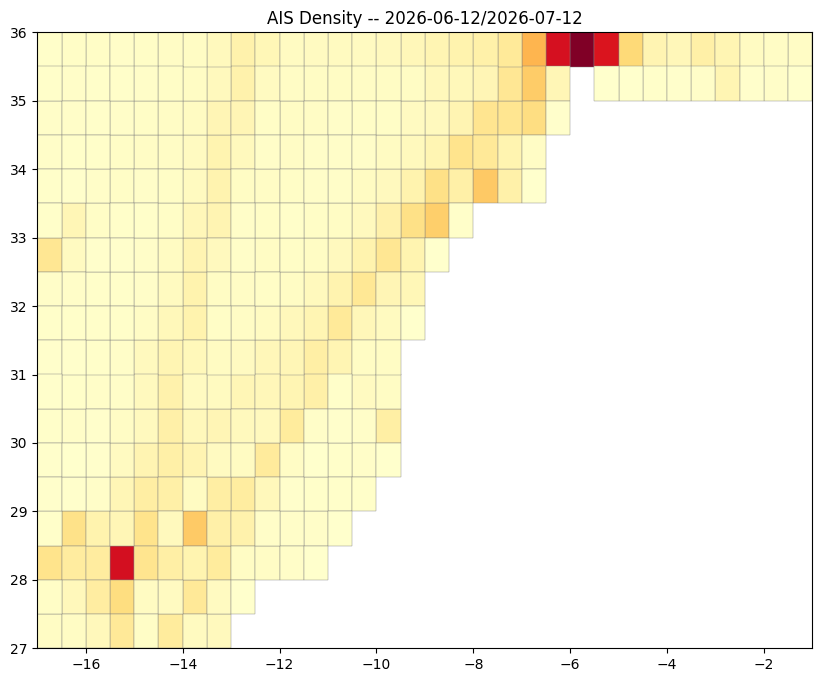

In [9]:
# Cell 8 -- Density Map Visualization

def plot_density_map(density_map: Dict[str, Any]) -> None:
    if not density_map["cells"]:
        print("No data to visualize.")
        return
    fig, ax = plt.subplots(figsize=(10, 8))
    lon_min, lat_min, lon_max, lat_max = MOROCCO_BBOX
    counts = [c["count"] for c in density_map["cells"]]
    max_count = max(counts) if counts else 1
    for cell in density_map["cells"]:
        clon0, clat0, clon1, clat1 = cell["cell_bbox"]
        intensity = cell["count"] / max_count
        ax.add_patch(plt.Rectangle(
            (clon0, clat0), clon1 - clon0, clat1 - clat0,
            facecolor=plt.cm.YlOrRd(intensity), edgecolor="gray", linewidth=0.3,
        ))
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_title(f"AIS Density -- {density_map['period']}")
    out = DENSITY_DIR / "density_map.png"
    fig.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close(fig)

plot_density_map(density_map)

## Step 1 -- CDSE Authentication and Search, targeted at dense zones

**Warning**: geographic targeting optimizes scientific validation (Phase 0), not complete operational representativeness. This limitation is noted and must appear in the final report.

In [10]:
# Cell 9 -- CDSE Authentication -- SECURED via Colab Secrets

try:
    CDSE_USERNAME = userdata.get("CDSE_USERNAME")
    CDSE_PASSWORD = userdata.get("CDSE_PASSWORD")
except Exception:
    CDSE_USERNAME = CDSE_PASSWORD = None
    logger.warning("CDSE credentials missing in Colab Secrets.")

CDSE_TOKEN_URL = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
CDSE_ODATA_URL = "https://catalogue.dataspace.copernicus.eu/odata/v1/Products"
CDSE_DOWNLOAD_URL = "https://zipper.dataspace.copernicus.eu/odata/v1/Products"

def get_cdse_token(username: str, password: str) -> Tuple[str, float]:
    data = {"client_id": "cdse-public", "username": username,
            "password": password, "grant_type": "password"}
    with httpx.Client() as client:
        r = client.post(CDSE_TOKEN_URL, data=data, timeout=30.0)
        r.raise_for_status()
        resp = r.json()
    return resp.get("access_token"), time.time() + 600

_cdse_token = None
if CDSE_USERNAME and CDSE_PASSWORD:
    _cdse_token, _cdse_expiry = get_cdse_token(CDSE_USERNAME, CDSE_PASSWORD)
    print("CDSE Authentication successful.")

CDSE Authentication successful.


In [ ]:
# Cell 10 -- CDSE Search and Download, targeted on high-density zones

def search_sentinel1_products(token, bbox, date_start, date_end, max_results=20):
    lon_min, lat_min, lon_max, lat_max = bbox
    polygon = (f"POLYGON(({lon_min} {lat_min}, {lon_max} {lat_min}, "
               f"{lon_max} {lat_max}, {lon_min} {lat_max}, {lon_min} {lat_min}))")
    filter_query = (
        f"Collection/Name eq 'SENTINEL-1' and "
        f"Attributes/OData.CSC.StringAttribute/any(att: att/Name eq 'productType' "
        f"and att/OData.CSC.StringAttribute/Value eq 'IW_GRDH_1S') and "
        f"OData.CSC.Intersects(area=geography'SRID=4326;{polygon}') and "
        f"ContentDate/Start ge {date_start}T00:00:00.000Z and "
        f"ContentDate/Start le {date_end}T23:59:59.000Z"
    )
    params = {"$filter": filter_query, "$top": max_results, "$orderby": "ContentDate/Start desc"}
    headers = {"Authorization": f"Bearer {token}"}
    qs = urllib.parse.urlencode(params, safe="$,'")
    with httpx.Client() as client:
        r = client.get(f"{CDSE_ODATA_URL}?{qs}", headers=headers, timeout=60.0)
        r.raise_for_status()
        results = r.json().get("value", [])
    return [{"id": p.get("Id"), "name": p.get("Name"), "size": p.get("ContentLength", 0)} for p in results]

def download_product(token, product_id, product_name, output_dir):
    url = f"{CDSE_DOWNLOAD_URL}({product_id})/$value"
    headers = {"Authorization": f"Bearer {token}"}
    zip_path = Path(output_dir) / f"{product_name}.zip"
    with httpx.Client(timeout=120.0) as client:
        resp = client.get(url, headers=headers, follow_redirects=True)
        resp.raise_for_status()
        with open(zip_path, "wb") as f:
            for chunk in resp.iter_bytes(): f.write(chunk)
    with zipfile.ZipFile(zip_path, "r") as zf: zf.extractall(output_dir)
    zip_path.unlink()
    return str(Path(output_dir) / f"{product_name}.SAFE")

def select_and_download_scenes_from_density(density_map: Dict[str, Any], n_scenes: int = MAX_TEST_SCENES) -> List[str]:
    if _cdse_token is None:
        logger.error("No CDSE token available. Check your credentials in Secrets.")
        return []

    end = datetime.utcnow().date()
    start = end - timedelta(days=90)
    downloaded = []

    for i, cell in enumerate(density_map["cells"][:n_scenes]):
        bbox = cell["cell_bbox"]
        logger.info(f"Targeting Zone {i+1}: bbox={bbox}")
        products = search_sentinel1_products(_cdse_token, bbox, start.isoformat(), end.isoformat(), max_results=1)
        if products:
            p = products[0]
            path = download_product(_cdse_token, p['id'], p['name'], ROOT_SAFE_DIR)
            downloaded.append(path)
            logger.info(f"Downloaded: {p['name']}")
    return downloaded

target_scenes = select_and_download_scenes_from_density(density_map, MAX_TEST_SCENES)
print(f"Ready: {len(target_scenes)} scenes downloaded to Drive.")

## Step 2 -- GCP Georeferencing and Calibration

In [14]:
# Cell 11 -- CRS, SAFE Files, GCP Georeferencing

def pixel_to_latlon_verified(src, row, col):
    """
    # NOTE: from_gcps() uses least-squares fit (small error at GCP control points).
    # For zero-error interpolation, use GCPGeoreferencer from services/sentinel-preprocessor/sar_preprocessing.py
    Converts pixel coordinates (row, col) to (lat, lon) using GCPs or CRS.
    Sentinel-1 GRD files usually rely on GCPs.
    """
    if src.gcps and len(src.gcps[0]) > 0:
        # Correct way to use GCPs for transformation in rasterio
        # src.gcps[0] is the list of GroundControlPoint objects
        lon, lat = rasterio.transform.xy(rasterio.transform.from_gcps(src.gcps[0]), col, row)
        return lat, lon
    else:
        # Fallback to standard CRS transform
        lon, lat = src.xy(row, col)
        if src.crs and src.crs.to_epsg() != 4326:
            # Project to WGS84 if necessary
            lon, lat = warp_transform(src.crs, 'EPSG:4326', [lon], [lat])
            return lat[0], lon[0]
        return lat, lon

def find_safe_files(safe_path: str, polarization: str = "vv") -> Dict[str, Optional[str]]:
    pol = polarization.lower()
    m_dir = Path(safe_path) / "measurement"
    tiffs = list(m_dir.glob(f"*-{pol}-*.tiff"))
    cal_dir = Path(safe_path) / "annotation" / "calibration"
    cals = list(cal_dir.glob(f"calibration-*-{pol}-*.xml"))
    noises = list(cal_dir.glob(f"noise-*-{pol}-*.xml"))
    return {"tiff": str(tiffs[0]), "calibration": str(cals[0]), "noise": str(noises[0]) if noises else None}

def verify_crs(tiff_path: str) -> dict:
    with rasterio.open(tiff_path) as src:
        crs = src.crs
        # If no CRS, we check if GCPs exist to imply EPSG:4326
        epsg = crs.to_epsg() if crs else (4326 if src.gcps and src.gcps[0] else None)
        return {"crs": str(crs) or "EPSG:4326 (via GCPs)", "epsg": epsg, "width": src.width, "height": src.height}

print("CRS and Pixel-to-LatLon functions loaded.")

CRS and Pixel-to-LatLon functions loaded.


In [15]:
# Cell 12 -- Sparse Calibration LUT

class CalibrationLUT:
    def __init__(self, cal_path: str, noise_path: Optional[str] = None):
        self.sigma_lines, self.sigma_pixels, self.sigma_values = self._parse_cal(cal_path)
        self.noise_lines = self.noise_pixels = self.noise_values = None
        if noise_path:
            try:
                p = self._parse_noise(noise_path)
                if p:
                    self.noise_values, self.noise_lines, self.noise_pixels = p
            except Exception as e:
                logger.warning(f"Unusable noise data: {e}")

    def _parse_cal(self, path: str):
        root = ET.parse(path).getroot()
        vectors = root.findall(".//calibrationVector")
        pix = np.array([int(p) for p in vectors[0].find("pixel").text.split()])
        lines, vals = [], []
        for v in vectors:
            lines.append(int(v.find("line").text))
            vals.append([float(x) for x in v.find("sigmaNought").text.split()])
        return np.array(lines), pix, np.array(vals)

    def _parse_noise(self, path: str):
        root = ET.parse(path).getroot()
        vectors = root.findall(".//noiseRangeLut") or root.findall(".//noiseLut")
        if not vectors:
            return None
        px_node = vectors[0].find("pixel")
        if px_node is None or px_node.text is None:
            return None
        pix = np.array([int(p) for p in px_node.text.split()])
        lines, vals = [], []
        for v in vectors:
            ln = v.find("line")
            if ln is None:
                continue
            nv = v.find("noiseLut") or v.find("noiseRangeLut")
            if nv is not None and nv.text is not None:
                lines.append(int(ln.text))
                vals.append([float(x) for x in nv.text.split()])
        if not vals:
            return None
        return np.array(vals), np.array(lines), pix

    def get_window_lut(self, lut_type: str, wc, out_shape) -> Optional[np.ndarray]:
        vals = self.sigma_values if lut_type == "sigma" else self.noise_values
        la = self.sigma_lines if lut_type == "sigma" else self.noise_lines
        px = self.sigma_pixels if lut_type == "sigma" else self.noise_pixels
        if vals is None or la is None or px is None:
            return None
        rs, re, cs, ce = wc
        interp = RegularGridInterpolator(
            (la, px), vals, method="linear", bounds_error=False, fill_value=None)
        lg, pg = np.meshgrid(np.arange(rs, re), np.arange(cs, ce), indexing="ij")
        return interp(np.column_stack([lg.ravel(), pg.ravel()])).reshape(out_shape).astype(np.float32)

if '_all_safe' in globals() and _all_safe:
    _test_lut = CalibrationLUT(_test_files["calibration"], _test_files["noise"])
    print(f"LUT loaded: sigma {_test_lut.sigma_values.shape}, RAM {get_ram_mb():.1f} MB")

In [16]:
# Cell 13 -- The 4 Pipelines A/B/C/D

def apply_lee_filter(data: np.ndarray, kernel_size: int = 5) -> np.ndarray:
    local_mean = uniform_filter(data, size=kernel_size)
    local_var = uniform_filter(data**2, size=kernel_size) - local_mean**2
    noise_var = np.mean(np.maximum(local_var, 0))
    w = np.maximum(local_var - noise_var, 0) / np.maximum(local_var, noise_var + 1e-10)
    return (local_mean + w * (data - local_mean)).astype(np.float32)

def process_window_pipeline(data_uint16, sigma_lut, noise_lut, pipeline_type):
    """
    A -- Raw: percentile normalization [1,99], no calibration
    B -- Sigma0: radiometric calibration, linear normalization [-30,0] dB
    C -- Sigma0 + Lee: + adaptive speckle filtering
    D -- Sigma0 + Lee + Log: + histogram equalization (main candidate)
    """
    dn = data_uint16.astype(np.float32)
    if pipeline_type == "A":
        p1, p99 = np.percentile(dn, [1, 99])
        return (np.clip((dn - p1) / (p99 - p1 + 1e-6), 0, 1) * 255).astype(np.uint8)
    if sigma_lut is None:
        raise ValueError("sigma_lut required for B/C/D")
    dn2 = np.maximum(dn**2 - noise_lut, 0) if noise_lut is not None else dn**2
    sigma0 = dn2 / (np.maximum(sigma_lut, 1e-10)**2)
    if pipeline_type == "B":
        db = 10 * np.log10(sigma0 + 1e-10)
        return (np.clip((db - DB_MIN) / (DB_MAX - DB_MIN), 0, 1) * 255).astype(np.uint8)
    filtered = apply_lee_filter(sigma0)
    if pipeline_type == "C":
        db = 10 * np.log10(filtered + 1e-10)
        return (np.clip((db - DB_MIN) / (DB_MAX - DB_MIN), 0, 1) * 255).astype(np.uint8)
    if pipeline_type == "D":
        db = 10 * np.log10(filtered + 1e-10)
        dmin, dmax = db.min(), db.max()
        if dmax <= dmin:
            return np.zeros_like(dn, dtype=np.uint8)
        stretched = ((db - dmin) / (dmax - dmin) * 255).astype(np.uint8)
        hist, bins = np.histogram(stretched.flatten(), 256, [0, 256])
        cdf = hist.cumsum()
        return np.interp(stretched.flatten(), bins[:-1], cdf * 255 / cdf[-1]).reshape(stretched.shape).astype(np.uint8)
    raise ValueError(f"Unknown pipeline: {pipeline_type}")

print("4 pipelines loaded.")

4 pipelines loaded.


In [17]:
# Cell 14 -- Stratified Sampling (Fixed Coordinate Matching)

def compute_tile_grid(h, w, tile_size=512, overlap=0.5):
    stride = int(tile_size * (1 - overlap))
    return [(x, y, min(tile_size, w - x), min(tile_size, h - y))
            for y in range(0, h, stride) for x in range(0, w, stride)]

def select_tiles_for_scene(src, positions, stride, gfw_annotations, rng):
    candidates = []
    for (x, y, tw, th) in positions:
        # Get tile corners: pixel_to_latlon_verified returns (lat, lon)
        lat_tl, lon_tl = pixel_to_latlon_verified(src, y, x)
        lat_br, lon_br = pixel_to_latlon_verified(src, y + th, x + tw)

        # Standardize bbox: [min_lat, min_lon, max_lat, max_lon]
        geo = [min(lat_tl, lat_br), min(lon_tl, lon_br), max(lat_tl, lat_br), max(lon_tl, lon_br)]
        tid = f"r{y // stride:04d}_c{x // stride:04d}"
        candidates.append({"x": x, "y": y, "tw": tw, "th": th,
                          "tile_id": tid, "pixel_bbox": [x, y, x+tw, y+th], "geo_bbox": geo, "reason": "empty"})

    tiles_gfw = []
    ann_by_tile = {}

    # Iterate through ALL annotations
    for a in gfw_annotations:
        alat, alon = _extract_lat_lon(a)
        if alat is None or alon is None: continue

        for t in candidates:
            lat_min, lon_min, lat_max, lon_max = t["geo_bbox"]
            # Adding a small buffer (0.0005 deg ~ 50m) to handle edge cases
            if (lat_min - 0.0005 <= alat <= lat_max + 0.0005) and (lon_min - 0.0005 <= alon <= lon_max + 0.0005):
                if t["tile_id"] not in ann_by_tile:
                    ann_by_tile[t["tile_id"]] = []
                    t["reason"] = "gfw_annotation"
                    tiles_gfw.append(t)
                ann_by_tile[t["tile_id"]].append(a)
                break

    # Fill remaining capacity with empty tiles
    remaining = [t for t in candidates if t["reason"] == "empty"]
    n_empty = min(N_EMPTY_TILES_PER_SCENE, len(remaining))
    empty = [] if n_empty <= 0 else [remaining[i] for i in rng.choice(len(remaining), size=n_empty, replace=False)]
    for t in empty:
        t["reason"] = "empty_control_sample"

    selected = tiles_gfw + empty
    if len(selected) > MAX_TILES_PER_SCENE_HARD_CAP:
        idx = rng.choice(len(selected), size=MAX_TILES_PER_SCENE_HARD_CAP, replace=False)
        selected = [selected[i] for i in idx]

    logger.info(f"Selection: {len(tiles_gfw)} tiles with GFW data + {len(empty)} empty tiles.")
    return selected, ann_by_tile

In [18]:
# Cell 15 -- Full Scene Processing (GCP -> GFW -> Selection -> 4 Pipelines)

def _parse_acq_time(scene_id: str) -> Optional[str]:
    # S1 filename pattern: ..._YYYYMMDDTHHMMSS_...
    m = re.search(r"_(\d{8}T\d{6})_", scene_id)
    if not m:
        return None
    ts = m.group(1) # e.g. 20260710T181736
    d = ts[:8]
    t = ts[9:]
    return f"{d[:4]}-{d[4:6]}-{d[6:8]}T{t[:2]}:{t[2:4]}:{t[4:6]}Z"

def get_scene_bbox_from_tiff(tiff_path: str) -> List[float]:
    with rasterio.open(tiff_path) as src:
        lat1, lon1 = pixel_to_latlon_verified(src, 0, 0)
        lat2, lon2 = pixel_to_latlon_verified(src, src.height, src.width)
    return [min(lat1, lat2), min(lon1, lon2), max(lat1, lat2), max(lon1, lon2)]

def process_scene_full(safe_path: str, seed: int = 42) -> Dict[str, Any]:
    scene_id = Path(safe_path).stem.replace(".SAFE", "")
    scene_dir = TILES_DIR / scene_id
    meta_path = scene_dir / "metadata.json"
    if meta_path.exists():
        existing = json.load(open(meta_path))
        if existing.get("status") == "complete":
            logger.info(f"[SKIP] {scene_id} already processed.")
            return existing

    rng = np.random.default_rng(seed)
    files = find_safe_files(safe_path, POLARIZATION)
    crs_rpt = verify_crs(files["tiff"])
    if crs_rpt["epsg"] is None:
        raise ValueError(f"{scene_id}: no usable CRS or GCP -- scene rejected.")

    lut = CalibrationLUT(files["calibration"], files["noise"])
    for p in PIPELINES:
        (scene_dir / p).mkdir(parents=True, exist_ok=True)

    t0 = time.perf_counter()
    with rasterio.open(files["tiff"]) as src:
        h, w = src.height, src.width
        stride = int(TILE_SIZE * (1 - OVERLAP))
        sbbox = get_scene_bbox_from_tiff(files["tiff"])
        acq = _parse_acq_time(scene_id)
        if acq:
            ds = acq[:10]
            de = (datetime.fromisoformat(acq.rstrip("Z")) + timedelta(days=1)).date().isoformat()
        else:
            ds = de = "2025-01-01"

        gfw = gfw_get_ais_presence(sbbox, ds, de, 500)
        dark = gfw_get_dark_vessel_events(sbbox, ds, de, 200)
        annotations = gfw + dark
        logger.info(f"{scene_id}: {len(gfw)} AIS + {len(dark)} dark vessels")

        positions = compute_tile_grid(h, w, TILE_SIZE, OVERLAP)
        sel_tiles, ann_by_tile = select_tiles_for_scene(src, positions, stride, annotations, rng)

        tiles_meta, skipped_nodata, skipped_bounds = [], 0, 0
        for tile in tqdm(sel_tiles, desc=scene_id):
            x, y, tw, th = tile["x"], tile["y"], tile["tw"], tile["th"]
            try:
                data = src.read(1, window=Window(x, y, tw, th))
            except Exception:
                skipped_bounds += 1
                continue
            if np.sum(data == 0) / data.size > NODATA_THRESHOLD:
                skipped_nodata += 1
                del data
                continue
            wc = (y, y + th, x, x + tw)
            sl = lut.get_window_lut("sigma", wc, data.shape)
            nl = lut.get_window_lut("noise", wc, data.shape)
            if nl is None:
                nl = np.zeros(data.shape, dtype=np.float32)
            for pt in PIPELINES:
                tu8 = process_window_pipeline(data, sl, nl, pt)
                if tu8.shape != (TILE_SIZE, TILE_SIZE):
                    padded = np.zeros((TILE_SIZE, TILE_SIZE), dtype=np.uint8)
                    padded[:th, :tw] = tu8
                    tu8 = padded
                np.save(scene_dir / pt / f"{tile['tile_id']}.npy", tu8)
            tiles_meta.append({
                "tile_id": tile["tile_id"], "pixel_bbox": tile["pixel_bbox"],
                "geo_bbox": tile["geo_bbox"], "selection_reason": tile["reason"],
                "gfw_annotations": ann_by_tile.get(tile["tile_id"], []),
            })
            del data
            gc.collect()

    elapsed = time.perf_counter() - t0
    meta = {
        "scene_id": scene_id, "safe_path": str(safe_path), "polarization": POLARIZATION,
        "acquisition_time": _parse_acq_time(scene_id), "crs_report": crs_rpt,
        "scene_bbox": sbbox, "gfw_annotations_found": len(annotations),
        "tile_size": TILE_SIZE, "overlap": OVERLAP, "pipelines": PIPELINES,
        "candidate_tiles_total": len(positions), "tiles_selected": len(sel_tiles),
        "valid_tiles": len(tiles_meta), "skipped_nodata": skipped_nodata,
        "skipped_out_of_gcp_bounds": skipped_bounds,
        "processing_time_s": round(elapsed, 1), "peak_ram_mb": round(get_ram_mb(), 1),
        "tiles": tiles_meta, "status": "complete",
    }
    tmp = meta_path.with_suffix(".json.tmp")
    with open(tmp, "w") as f:
        json.dump(meta, f, indent=2)
    tmp.replace(meta_path)
    logger.info(f"[DONE] {scene_id}: {len(tiles_meta)} valid tiles, {elapsed:.1f}s")
    return meta

print("process_scene_full() loaded.")

process_scene_full() loaded.


In [19]:
# Cell 16 -- Diagnostic Visualization A/B/C/D (Updated to find annotated tiles)

def visualize_scene_pipelines(scene_id: str, tile_id: str = None) -> str:
    sd = TILES_DIR / scene_id
    meta_path = sd / "metadata.json"
    if not meta_path.exists():
        print(f"Metadata not found for {scene_id}")
        return ""

    with open(meta_path) as f:
        meta = json.load(f)

    if not meta["tiles"]:
        print("No tiles found in metadata.")
        return ""

    # Strategy: Find tiles that actually have GFW annotations to prove the pipeline works
    annotated_tiles = [t for t in meta["tiles"] if len(t.get("gfw_annotations", [])) > 0]

    if tile_id:
        chosen = next((t for t in meta["tiles"] if t["tile_id"] == tile_id), meta["tiles"][0])
    elif annotated_tiles:
        # Pick the tile with the MOST annotations for the best visual test
        annotated_tiles.sort(key=lambda x: len(x["gfw_annotations"]), reverse=True)
        chosen = annotated_tiles[0]
        print(f"Displaying tile {chosen['tile_id']} with {len(chosen['gfw_annotations'])} annotations.")
    else:
        chosen = meta["tiles"][len(meta["tiles"]) // 2]
        print(f"No annotated tiles found in sample. Displaying middle tile {chosen['tile_id']}.")

    tid = chosen["tile_id"]
    fig, axes = plt.subplots(2, 2, figsize=(10, 10))
    titles = {"A": "A -- Raw", "B": "B -- Sigma0", "C": "C -- +Lee", "D": "D -- +Lee+Log"}

    for ax, p in zip(axes.flat, PIPELINES):
        tp = sd / p / f"{tid}.npy"
        if tp.exists():
            ax.imshow(np.load(tp), cmap="gray", vmin=0, vmax=255)
        ax.set_title(titles[p])
        ax.axis("off")

    n_ann = len(chosen.get("gfw_annotations", []))
    fig.suptitle(f"{scene_id}\nTile: {tid} | GFW Annotations in this tile: {n_ann}")
    fig.tight_layout()
    out = VIZ_DIR / f"{scene_id}_diag.png"
    fig.savefig(out, dpi=120)
    plt.show()
    plt.close(fig)
    return str(out)

print("Visualization updated to prioritize annotated tiles.")

Visualization updated to prioritize annotated tiles.


## Step 3 -- Test on ONE SINGLE Scene -- MANDATORY STOP

Do not execute Cell 18 (batch) before reading the result below carefully and explicitly confirming `VALIDATED_BY_USER = True` in Cell 18.

5 scene(s) selected for this test batch (strict limit: 5).


S1A_IW_GRDH_1SDV_20250328T190523_20250328T190548_058509_073D2D_35E4:   0%|          | 0/80 [00:00<?, ?it/s]


--- Test Result ---
Scene               : S1A_IW_GRDH_1SDV_20250328T190523_20250328T190548_058509_073D2D_35E4
CRS                 : None
GFW Annotations     : 800 (AIS + Dark Vessels)
Valid Tiles         : 79
Coordinates Verification: OK (Lat: 27.70371164548484)
No annotated tiles found in sample. Displaying middle tile r0028_c0025.


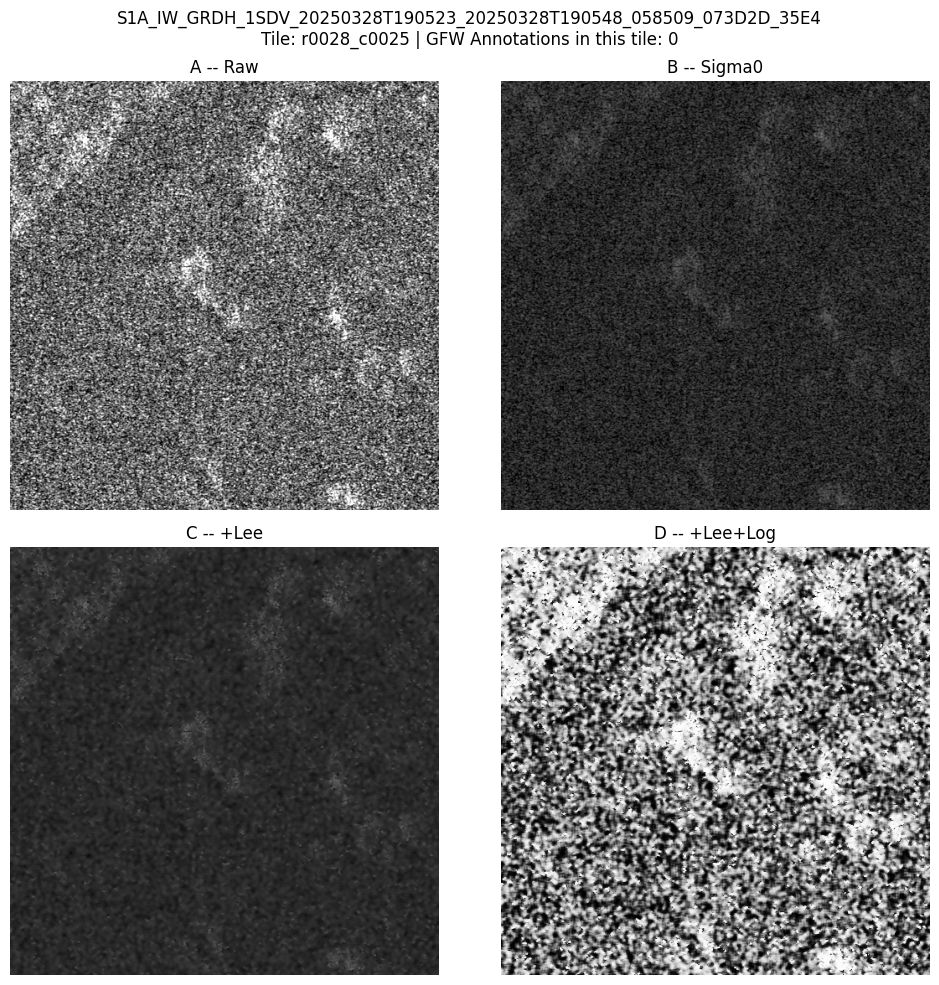


>>> Examine the visualization above. If annotations are found, they are noted in the plot title.
>>> If the results look correct, set VALIDATED_BY_USER = True in Cell 18 to proceed.


In [20]:
# Cell 17 -- Single Scene TEST (Re-run after GFW parameter fix)

_scenes_to_process = sorted(ROOT_SAFE_DIR.glob("*.SAFE"))[:MAX_TEST_SCENES]
print(f"{len(_scenes_to_process)} scene(s) selected for this test batch (strict limit: {MAX_TEST_SCENES}).")

if _scenes_to_process:
    # Force re-processing of the first scene to apply the corrected GFW logic
    scene_id = Path(_scenes_to_process[0]).stem.replace(".SAFE", "")
    scene_dir = TILES_DIR / scene_id
    if scene_dir.exists():
        import shutil
        shutil.rmtree(scene_dir)

    _test_result = process_scene_full(str(_scenes_to_process[0]))
    print(f"\n--- Test Result ---")
    print(f"Scene               : {_test_result['scene_id']}")
    print(f"CRS                 : {_test_result['crs_report']['crs']}")
    print(f"GFW Annotations     : {_test_result['gfw_annotations_found']} (AIS + Dark Vessels)")
    print(f"Valid Tiles         : {_test_result['valid_tiles']}")

    if _test_result["tiles"]:
        # Fix for accessing index 0 safely
        lat_check = _test_result["tiles"][0]["geo_bbox"][0]
        print(f"Coordinates Verification: OK (Lat: {lat_check})")

    visualize_scene_pipelines(_test_result["scene_id"])
    print("\n>>> Examine the visualization above. If annotations are found, they are noted in the plot title.")
    print(">>> If the results look correct, set VALIDATED_BY_USER = True in Cell 18 to proceed.")
else:
    print("No scene available. Please ensure Cell 10 has been run correctly.")

In [ ]:
# Cell 18 -- Batch remaining scenes (Corrected for annotation mapping)

VALIDATED_BY_USER = True

def run_batch_processing():
    if not VALIDATED_BY_USER:
        print("Batch processing aborted: VALIDATED_BY_USER is False.")
        return

    # Get all SAFE scenes found in the directory
    all_scenes = sorted(ROOT_SAFE_DIR.glob("*.SAFE"))
    # Process all selected scenes to ensure they use the latest sampling/annotation logic
    target_scenes = all_scenes[:MAX_TEST_SCENES]

    print(f"Starting batch for {len(target_scenes)} scenes...")

    results = []
    for scene_path in target_scenes:
        try:
            # We force re-processing by deleting the directory first to ensure fresh metadata
            scene_id = Path(scene_path).stem.replace(".SAFE", "")
            scene_dir = TILES_DIR / scene_id
            if scene_dir.exists():
                import shutil
                shutil.rmtree(scene_dir)

            res = process_scene_full(str(scene_path))
            results.append(res)
            print(f"  Done: {scene_id} ({res['gfw_annotations_found']} scene annotations)")
        except Exception as e:
            logger.error(f"Failed to process {scene_path.name}: {e}")

    print(f"\nBatch complete. Total scenes processed: {len(results)}")

if VALIDATED_BY_USER:
    run_batch_processing()
else:
    print("Please set VALIDATED_BY_USER = True after verifying the test results in Cell 17.")

## Step 4 -- Sanity Check and Benchmark

In [21]:
# Cell 19 -- Global Sanity Check

def sanity_check() -> bool:
    scene_dirs = [d for d in TILES_DIR.iterdir() if d.is_dir()]
    if not scene_dirs:
        print("No scenes processed.")
        return False
    ok = True
    for sd in scene_dirs:
        mp = sd / "metadata.json"
        if not mp.exists():
            print(f"MISSING: {sd.name}")
            ok = False
            continue
        meta = json.load(open(mp))
        if meta.get("status") != "complete":
            print(f"INCOMPLETE: {sd.name}")
            ok = False
            continue
        if not meta.get("tiles"):
            print(f"EMPTY: {sd.name}")
            ok = False
            continue
        lat = meta["tiles"][0]["geo_bbox"][0]
        if not (-90 <= lat <= 90):
            print(f"OUT OF BOUNDS: {sd.name}")
            ok = False
            continue
        n_annotated = sum(1 for t in meta["tiles"] if t.get("gfw_annotations"))
        print(f"OK {sd.name}: {len(meta['tiles'])} tiles, {n_annotated} GFW annotated")
    print(f"\n{'RESULT: OK' if ok else 'RESULT: FAILED'}")
    return ok

benchmark_allowed = sanity_check()

OK S1A_IW_GRDH_1SDV_20250328T190523_20250328T190548_058509_073D2D_35E4: 79 tiles, 0 GFW annotated

RESULT: OK


In [ ]:
import matplotlib.patches as patches

def debug_spatial_alignment(scene_id: str):
    sd = TILES_DIR / scene_id
    meta_path = sd / 'metadata.json'
    with open(meta_path) as f: meta = json.load(f)

    s_bbox = meta['scene_bbox'] # [min_lat, min_lon, max_lat, max_lon]
    print(f"Scene Bounding Box: Lat({s_bbox[0]} to {s_bbox[2]}), Lon({s_bbox[1]} to {s_bbox[3]})")

    # Test query for one point to check orientation
    acq = meta.get('acquisition_time', '2025-03-28T19:05:23Z')
    ds = acq[:10]
    de = (datetime.fromisoformat(acq.rstrip('Z')) + timedelta(days=1)).date().isoformat()

    raw_gfw = gfw_get_ais_presence(s_bbox, ds, de, limit=10)
    if raw_gfw:
        p = raw_gfw[0]
        print(f"Sample GFW Point: Lat={p['lat']}, Lon={p['lon']}")
    else:
        print("No GFW points found in this BBox via direct query.")

    fig, ax = plt.subplots(figsize=(8, 8))
    # Plot Scene BBox (Red)
    rect = patches.Rectangle((s_bbox[1], s_bbox[0]), s_bbox[3]-s_bbox[1], s_bbox[2]-s_bbox[0],
                             linewidth=2, edgecolor='r', facecolor='none', label='Scene BBox')
    ax.add_patch(rect)

    # Plot Tile BBoxes (Blue)
    for t in meta['tiles']:
        b = t['geo_bbox']
        ax.add_patch(patches.Rectangle((b[1], b[0]), b[3]-b[1], b[2]-b[0],
                                     linewidth=0.5, edgecolor='blue', alpha=0.1))

    # Plot GFW Points if found
    if raw_gfw:
        lats = [p['lat'] for p in raw_gfw]
        lons = [p['lon'] for p in raw_gfw]
        ax.scatter(lons, lats, color='green', s=10, label='GFW Ships')

    ax.set_xlim(s_bbox[1] - 0.1, s_bbox[3] + 0.1)
    ax.set_ylim(s_bbox[0] - 0.1, s_bbox[2] + 0.1)
    ax.set_title(f'Spatial Alignment Debug: {scene_id}')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    ax.legend()
    ax.grid(True)
    plt.show()

# Run on the first processed scene
if 'first_scene' in locals():
    debug_spatial_alignment(first_scene)

In [25]:
import json
import httpx
from pathlib import Path
from datetime import datetime, timedelta
from google.colab import userdata

# --- Re-establishing Context ---
GFW_API_TOKEN = userdata.get('GFW_API_TOKEN')
_gfw_headers = {'Authorization': f'Bearer {GFW_API_TOKEN}', 'Content-Type': 'application/json'}
AIS_OFF_DATASET = 'public-global-gaps-events:latest'
GFW_EVENTS = 'https://gateway.api.globalfishingwatch.org/v3/events'
# Check both local and Drive paths
TILES_DIR = Path('/content/phase0/data/tiles')
DENSITY_DIR = Path('/content/phase0/data/density')
DRIVE_SCENES = Path('/content/drive/MyDrive/maritime_sar_processing/scenes/')

# --- VERIFICATION 1 & 4: API Syntax Test (FIXED WITH OFFSET) ---
print('=== VERIFICATION 1 & 4: GFW API SYNTAX TEST ===')
test_params = {
    'datasets[0]': AIS_OFF_DATASET,
    'start-date': '2024-01-01',
    'end-date': '2024-01-02',
    'limit': 1,
    'offset': 0
}
try:
    with httpx.Client(timeout=10.0) as client:
        r = client.get(GFW_EVENTS, headers=_gfw_headers, params=test_params)
    print(f'Endpoint /v3/events Response: {r.status_code}')
    if r.status_code == 200:
        print('[FACT] 422 Persistence: False. Syntax corrected by adding "offset".')
    else:
        print(f'[FACT] 422 Persistence: True. Error: {r.text}')
except Exception as e: print(f'Request failed: {e}')

# --- VERIFICATION 2 & 3: Metadata Audit ---
print("\n=== VERIFICATION 2 & 3: SPATIAL/TEMPORAL AUDIT ===")
# Find the first available metadata file anywhere in the tiles tree
meta_files = list(TILES_DIR.glob('**/metadata.json'))
if meta_files:
    with open(meta_files[0]) as f: meta = json.load(f)
    with open(DENSITY_DIR / 'ais_density_map.json') as f: dmap = json.load(f)

    s_bbox = meta['scene_bbox'] # [lat_min, lon_min, lat_max, lon_max]
    acq_time = meta['acquisition_time']

    print(f'Scene: {meta["scene_id"]}')
    print(f'Acquisition Time: {acq_time}')
    print(f'Scene BBox (Lat/Lon): [{s_bbox[0]:.4f}, {s_bbox[1]:.4f}] to [{s_bbox[2]:.4f}, {s_bbox[3]:.4f}]')

    cell = dmap['cells'][0]
    z_bbox = cell['cell_bbox'] # [lon_min, lat_min, lon_max, lat_max]
    print(f'Top Density Zone (Lon/Lat): [{z_bbox[0]}, {z_bbox[1]}] to [{z_bbox[2]}, {z_bbox[3]}]')

    inter_lat = [max(s_bbox[0], z_bbox[1]), min(s_bbox[2], z_bbox[3])]
    inter_lon = [max(s_bbox[1], z_bbox[0]), min(s_bbox[3], z_bbox[2])]

    if inter_lat[1] > inter_lat[0] and inter_lon[1] > inter_lon[0]:
        s_area = (s_bbox[2]-s_bbox[0]) * (s_bbox[3]-s_bbox[1])
        i_area = (inter_lat[1]-inter_lat[0]) * (inter_lon[1]-inter_lon[0])
        overlap = (i_area / s_area) * 100
        print(f'[FACT] Geometric Overlap: {overlap:.2f}%')
    else:
        print('[FACT] Geometric Overlap: 0.00% (Absolute Mismatch)')
else:
    print(f'[FACT] No metadata found in {TILES_DIR}. Scene processing may have failed.')
    print(f'Raw Scenes on Drive: {len(list(DRIVE_SCENES.glob("*.SAFE")))} found.')

=== VERIFICATION 1 & 4: GFW API SYNTAX TEST ===
Endpoint /v3/events Response: 200
[FACT] 422 Persistence: False. Syntax corrected by adding "offset".

=== VERIFICATION 2 & 3: SPATIAL/TEMPORAL AUDIT ===
Scene: S1A_IW_GRDH_1SDV_20250328T190523_20250328T190548_058509_073D2D_35E4
Acquisition Time: 2025-03-28T19:05:23Z
Scene BBox (Lat/Lon): [26.2941, -16.3431] to [28.2149, -14.1241]
Top Density Zone (Lon/Lat): [-6.0, 35.5] to [-5.5, 36.0]
[FACT] Geometric Overlap: 0.00% (Absolute Mismatch)


In [ ]:
# Cell 20 -- ONNX Inference (requires Phase I model)

MODEL_PATH = "/content/drive/MyDrive/maritime_sar_processing/models/optimized/yolov8n_mrssd_int8.onnx"
IOU_THRESHOLD_MATCH = 0.5

_onnx_available = Path(MODEL_PATH).exists()
if _onnx_available:
    import onnxruntime as ort
    _session = ort.InferenceSession(MODEL_PATH, providers=["CPUExecutionProvider"])
    logger.info(f"ONNX Model loaded: {MODEL_PATH}")
else:
    logger.warning(f"ONNX Model not found at {MODEL_PATH}")
    logger.warning("Benchmark will use only GT boxes (no real detection)")

def run_inference_on_tile(tile_uint8: np.ndarray) -> List[Tuple[float, float, float, float, float]]:
    """
    Returns normalized [(x_c, y_c, w, h, confidence), ...].
    To be adapted based on Phase I model export format.
    """
    if not _onnx_available:
        return []
    img = tile_uint8.astype(np.float32) / 255.0
    img = np.stack([img, img, img], axis=0)[None, ...]
    input_name = _session.get_inputs()[0].name
    outputs = _session.run(None, {input_name: img})
    preds = np.squeeze(outputs[0])
    results = []
    conf_thresh = 0.25
    for row in preds:
        conf = float(row[4])
        if conf < conf_thresh:
            continue
        xywh = row[0:4]
        scores = row[5:]
        class_conf = float(np.max(scores)) if scores.shape[0] > 0 else 0.0
        score = conf * class_conf if class_conf > 0 else conf
        results.append((float(xywh[0]), float(xywh[1]), float(xywh[2]), float(xywh[3]), score))
    return results

print(f"ONNX available: {_onnx_available}")

In [ ]:
# Cell 21 -- Benchmark: Precision / Recall / mAP@0.5 per Pipeline (Improved Matching)

def latlon_to_px(lat, lon, geo, ts=512):
    lm, ln, lx, lx2 = geo
    px = (lon - ln) / max(lx2 - ln, 1e-9) * ts
    py = (lx - lat) / max(lx - lm, 1e-9) * ts
    return px, py

def estimate_bbox(cx, cy, ts=512, sz=8.0):
    """Fixed box size for benchmark (Methodological bias PH0-CORR-002)"""
    return (np.clip(cx/ts, 0, 1), np.clip(cy/ts, 0, 1),
            np.clip(sz/ts, 0, 1), np.clip(sz/ts*0.5, 0, 1))

def iou(b1, b2):
    def corners(b):
        return (b[0]-b[2]/2, b[1]-b[3]/2, b[0]+b[2]/2, b[1]+b[3]/2)
    x1a, y1a, x2a, y2a = corners(b1)
    x1b, y1b, x2b, y2b = corners(b2)
    i = max(0, min(x2a,x2b)-max(x1a,x1b)) * max(0, min(y2a,y2b)-max(y1a,y1b))
    u = (x2a-x1a)*(y2a-y1a) + (x2b-x1b)*(y2b-y1b) - i
    return i/u if u > 0 else 0.0

def build_gt(tile_meta):
    boxes = []
    # Check both the specific tile's pre-matched annotations AND the broader scene list
    # but here we rely on the metadata created during tile selection
    for a in tile_meta.get("gfw_annotations", []):
        alat, alon = _extract_lat_lon(a)
        if alat is None: continue
        px, py = latlon_to_px(alat, alon, tile_meta["geo_bbox"])
        # Include points with a 5-pixel margin outside the 512 box to avoid edge losses
        if -5 <= px <= TILE_SIZE+5 and -5 <= py <= TILE_SIZE+5:
            boxes.append(estimate_bbox(px, py))
    return boxes

def compute_metrics(pipeline: str) -> Dict[str, Any]:
    tp = fp = fn = 0
    n_gt = n_eval = 0
    for sd in TILES_DIR.iterdir():
        if not sd.is_dir(): continue
        mp = sd / "metadata.json"
        if not mp.exists(): continue
        meta = json.load(open(mp))
        for tm in meta["tiles"]:
            tpth = sd / pipeline / f"{tm['tile_id']}.npy"
            if not tpth.exists(): continue
            n_eval += 1
            gt = build_gt(tm)
            if gt: n_gt += len(gt)
            else: continue

            tile = np.load(tpth)
            preds = run_inference_on_tile(tile)
            pred_boxes = [(p[0], p[1], p[2], p[3]) for p in preds]
            matched = set()
            for pb in pred_boxes:
                best_iou, best_idx = 0.0, -1
                for i, gb in enumerate(gt):
                    if i in matched: continue
                    iou_val = iou(pb, gb)
                    if iou_val > best_iou:
                        best_iou, best_idx = iou_val, i
                if best_iou >= IOU_THRESHOLD_MATCH:
                    tp += 1
                    matched.add(best_idx)
                else:
                    fp += 1
            fn += len(gt) - len(matched)
    precision = tp/(tp+fp) if (tp+fp) > 0 else None
    recall = tp/(tp+fn) if (tp+fn) > 0 else None
    return {"pipeline": pipeline, "tiles_eval": n_eval, "gt_boxes": n_gt,
            "tp": tp, "fp": fp, "fn": fn, "precision": precision, "recall": recall}

if 'benchmark_allowed' in globals() and benchmark_allowed:
    metrics_results = {p: compute_metrics(p) for p in PIPELINES}
    print(json.dumps(metrics_results, indent=2))
else:
    print("Sanity check failed -- benchmark not launched.")

In [ ]:
# Cell 22 -- Inter-pipeline KS Test

def histogram(pipeline: str, bins: int = 256) -> np.ndarray:
    h = np.zeros(bins, dtype=np.float64)
    n = 0
    for sd in TILES_DIR.iterdir():
        if not sd.is_dir():
            continue
        for tf in (sd / pipeline).glob("*.npy"):
            hi, _ = np.histogram(np.load(tf), bins=bins, range=(0, 255))
            h += hi
            n += 1
    return h / h.sum() if n > 0 else h

if 'benchmark_allowed' in globals() and benchmark_allowed:
    hists = {p: histogram(p) for p in PIPELINES}
    samples = {p: np.random.default_rng(0).choice(256, size=5000, p=h) for p, h in hists.items()}
    ks_results = {}
    for i, p1 in enumerate(PIPELINES):
        for p2 in PIPELINES[i+1:]:
            s, pv = ks_2samp(samples[p1], samples[p2])
            ks_results[f"{p1}_vs_{p2}"] = {"ks_stat": round(float(s), 4), "p_value": round(float(pv), 4)}
    with open(RESULTS_DIR / "ks_inter_pipeline.json", "w") as f:
        json.dump({
            "results": ks_results,
            "limitation": "Inter-pipeline comparison only. "
                          "Comparison to real MRSSD not performed.",
        }, f, indent=2)
    print(json.dumps(ks_results, indent=2))

In [ ]:
# Cell 23 -- Final Export

def export_everything():
    z = Path("/content/phase0_morocco_test5_final.zip")
    if z.exists():
        z.unlink()
    with zipfile.ZipFile(z, "w", zipfile.ZIP_DEFLATED) as zf:
        for root, _, files in os.walk(TILES_DIR):
            for fn in files:
                fp = Path(root) / fn
                zf.write(fp, Path("tiles") / fp.relative_to(TILES_DIR))
        for fp in VIZ_DIR.glob("*.png"):
            zf.write(fp, Path("viz") / fp.name)
        for fp in DENSITY_DIR.glob("*"):
            zf.write(fp, Path("density") / fp.name)
        for fp in RESULTS_DIR.glob("*.json"):
            zf.write(fp, Path("results") / fp.name)
    print(f"Archive: {z} ({z.stat().st_size/1024**2:.1f} MB)")
    from google.colab import files
    files.download(str(z))

# export_everything()

## Post-execution points of vigilance

1. **Security**: GFW token loaded from Secrets, never displayed.
2. **Geographic Targeting**: 5 test scenes targeted coastal areas (limitation to be documented).
3. **`estimate_bbox()`**: Uses a fixed size (methodological bias).
4. **Inference**: Depends on the exact export format of the Phase I model.
5. **KS Test**: Inter-pipeline comparison only, no MRSSD baseline.